In [1]:
!pip install nltk spacy wordcloud xgboost catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.2 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import re
import nltk
import spacy
import seaborn as sns
import matplotlib.pyplot as plt

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

import pickle

nltk.download('stopwords')

from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [3]:
from google.colab import files
uploaded = files.upload()

Saving Resume.csv to Resume.csv


In [4]:
df = pd.read_csv("Resume.csv")

**EXPLORE DATASET**

In [5]:
df.head() #View first 5 rows

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [6]:
df.shape

(2484, 4)

In [7]:
df.info() #Check structure

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB


In [8]:
df.columns

Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')

In [9]:
df.describe() #Check statistics

,ID
count,2.484000e+03
mean,3.182616e+07
std,2.145735e+07
min,3.547447e+06
25%,1.754430e+07
50%,2.521031e+07
75%,3.611444e+07
max,9.980612e+07


In [10]:
df.isnull().sum() #Fix Missing Data

,0
ID,0
Resume_str,0
Resume_html,0
Category,0


In [11]:
df['Category'].value_counts()

,count
Category,
INFORMATION-TECHNOLOGY,120
BUSINESS-DEVELOPMENT,120
ADVOCATE,118
CHEF,118
ENGINEERING,118
ACCOUNTANT,118
FINANCE,118
FITNESS,117
AVIATION,117


In [12]:
df.drop_duplicates(inplace=True)#  Remove duplicates

df.dropna(inplace=True)  # Remove missing values

print("Missing Values:")

print("\n")

print(df.isnull().sum())


Missing Values:


ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64


 **VISUALIZE CATEGORY DISTRIBUTION**

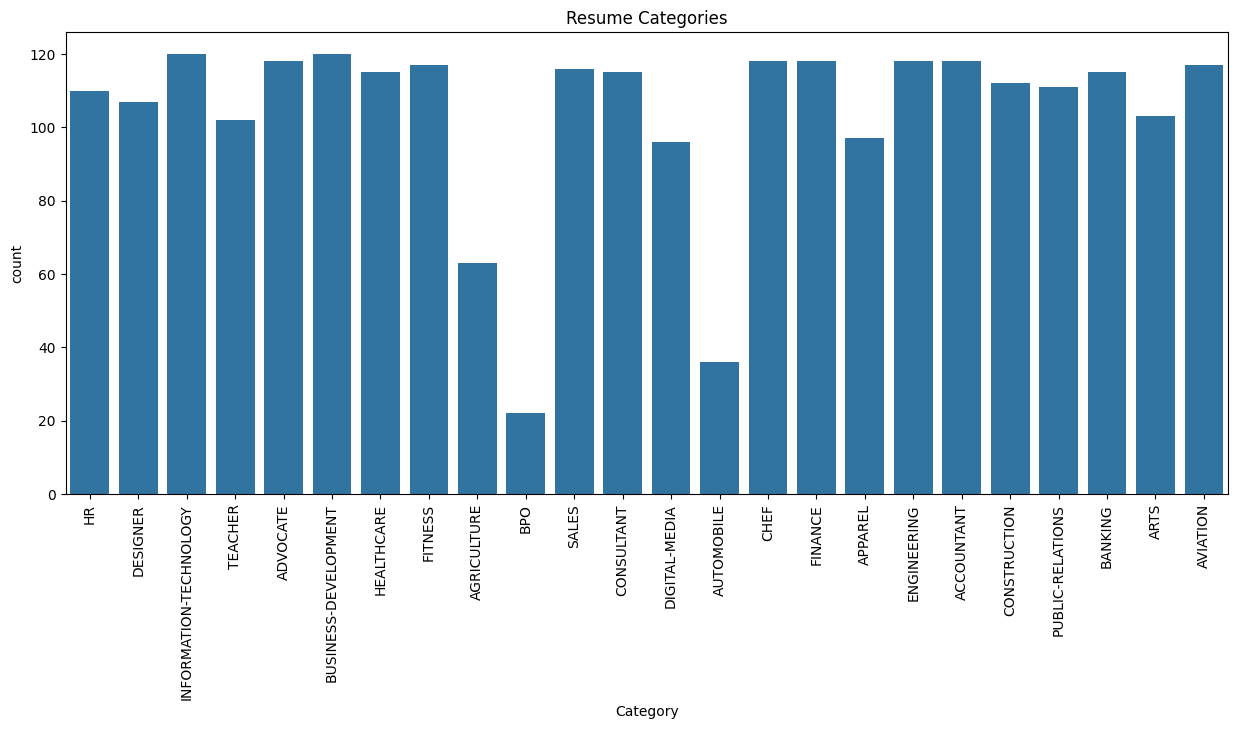

In [13]:
plt.figure(figsize=(15,6))

sns.countplot(x=df['Category'])

plt.xticks(rotation=90)

plt.title("Resume Categories")

plt.show()

**TEXT CLEANING FUNCTION**

In [14]:
stop_words = set(stopwords.words('english'))

def clean_resume(text):

    text = re.sub('http\S+\s*', ' ', text)

    text = re.sub('RT|cc', ' ', text)

    text = re.sub('#\S+', '', text)

    text = re.sub('@\S+', '  ', text)

    text = re.sub('[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\\]^_`{|}~"""), ' ', text)

    text = re.sub(r'[^\x00-\x7f]',r' ', text)

    text = re.sub('\s+', ' ', text)

    text = text.lower()

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

<>:5: SyntaxWarning: invalid escape sequence '\S'
<>:9: SyntaxWarning: invalid escape sequence '\S'
<>:11: SyntaxWarning: invalid escape sequence '\S'
<>:17: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\S'
<>:9: SyntaxWarning: invalid escape sequence '\S'
<>:11: SyntaxWarning: invalid escape sequence '\S'
<>:17: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3011/2424651359.py:5: SyntaxWarning: invalid escape sequence '\S'
  text = re.sub('http\S+\s*', ' ', text)
/tmp/ipykernel_3011/2424651359.py:9: SyntaxWarning: invalid escape sequence '\S'
  text = re.sub('#\S+', '', text)
/tmp/ipykernel_3011/2424651359.py:11: SyntaxWarning: invalid escape sequence '\S'
  text = re.sub('@\S+', '  ', text)
/tmp/ipykernel_3011/2424651359.py:17: SyntaxWarning: invalid escape sequence '\s'
  text = re.sub('\s+', ' ', text)


**APPLY CLEANING**

In [15]:
df['cleaned_resume'] = df['Resume_str'].apply(clean_resume)

**WORD CLOUD**

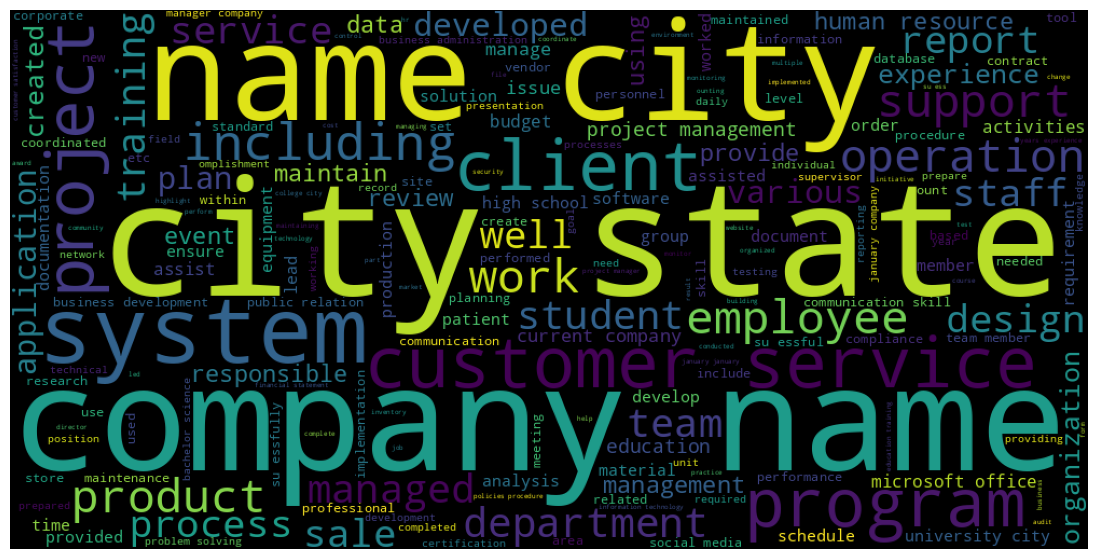

In [16]:
text = " ".join(df['cleaned_resume'])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='black'
).generate(text)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis('off')

plt.show()

**ENCODE LABELS**

In [17]:
le = LabelEncoder()

df['encoded_category'] = le.fit_transform(df['Category'])

**TF-IDF VECTORIZATION**

In [18]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X = tfidf.fit_transform(df['cleaned_resume'])

y = df['encoded_category']

**TRAIN TEST SPLIT**

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**TRAIN MULTIPLE MODELS**

**Logistic Regression**

In [20]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)

print("LOGISTIC REGRESSION ACCURACY")
print(accuracy_score(y_test, lr_preds))

LOGISTIC REGRESSION ACCURACY
0.6539235412474849


**Naive Bayes**

In [21]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_preds = nb_model.predict(X_test)

print("NAIVE BAYES ACCURACY")
print(accuracy_score(y_test, nb_preds))

NAIVE BAYES ACCURACY
0.579476861167002


**Random Forest**

In [22]:
rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

print("RANDOM FOREST ACCURACY")
print(accuracy_score(y_test, rf_preds))

RANDOM FOREST ACCURACY
0.7505030181086519


**XGBoost**

In [23]:
xgb_model = XGBClassifier()

xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)

print("XGBOOST ACCURACY")
print(accuracy_score(y_test, xgb_preds))

XGBOOST ACCURACY
0.7847082494969819


***ADVANCED GRAPHICAL REPRESENTATIONS***

1. **CATEGORY DISTRIBUTION PIE CHART**

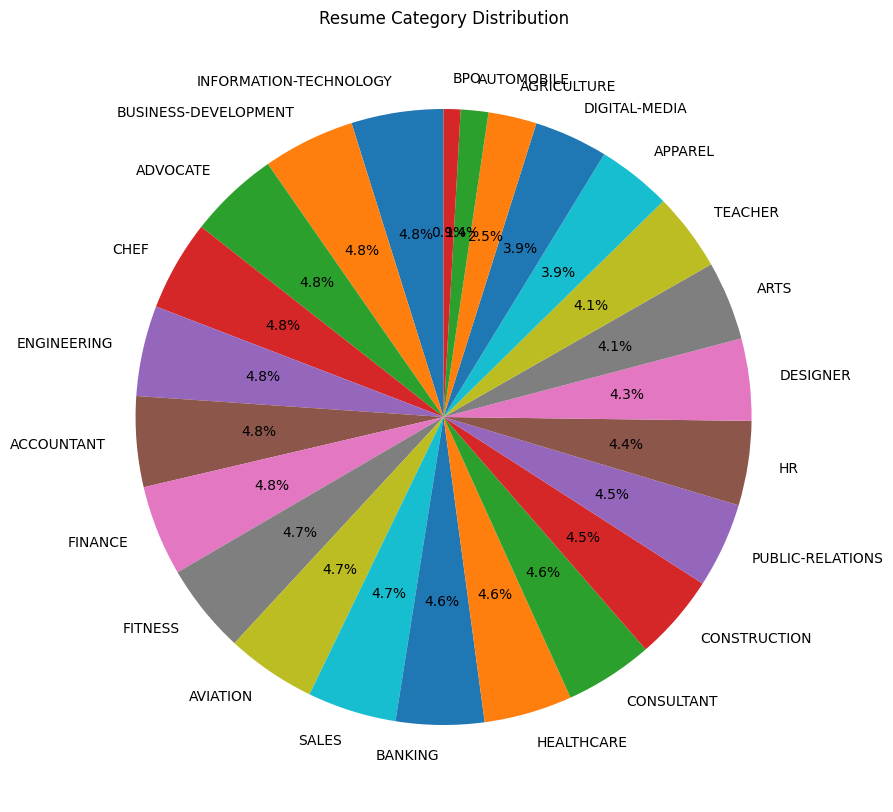

In [24]:
plt.figure(figsize=(10,10))

df['Category'].value_counts().plot.pie(
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Resume Category Distribution")

plt.ylabel('')

plt.show()

2. **TOP 20 MOST COMMON WORDS**

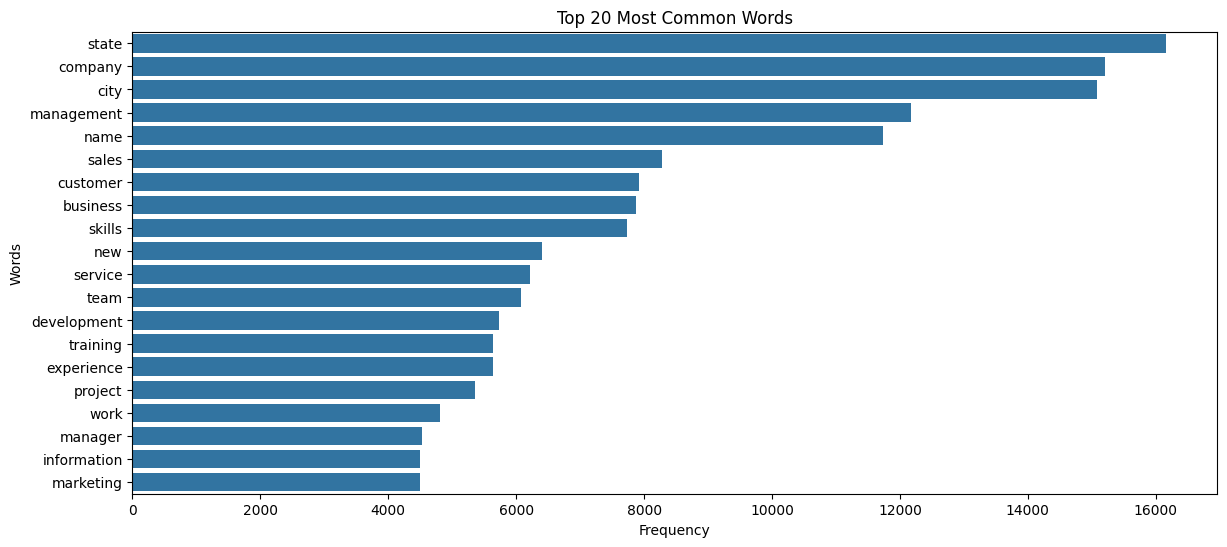

In [25]:
from collections import Counter

all_words = " ".join(df['cleaned_resume']).split()

word_freq = Counter(all_words)

common_words = word_freq.most_common(20)

words = [word[0] for word in common_words]
counts = [word[1] for word in common_words]

plt.figure(figsize=(14,6))

sns.barplot(x=counts, y=words)

plt.title("Top 20 Most Common Words")

plt.xlabel("Frequency")

plt.ylabel("Words")

plt.show()

3. **RESUME LENGTH DISTRIBUTION**

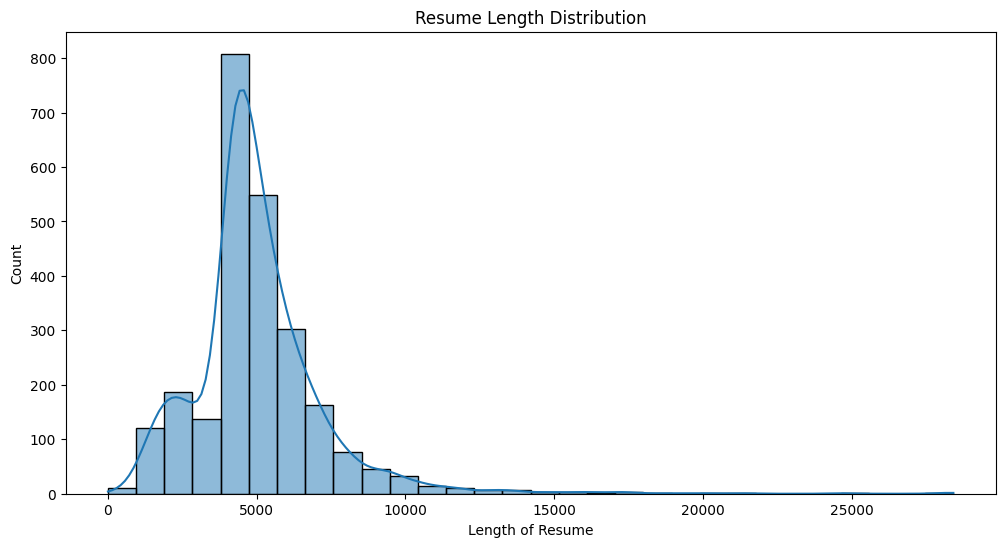

In [26]:
df['resume_length'] = df['cleaned_resume'].apply(len)

plt.figure(figsize=(12,6))

sns.histplot(df['resume_length'], bins=30, kde=True)

plt.title("Resume Length Distribution")

plt.xlabel("Length of Resume")

plt.ylabel("Count")

plt.show()

4. **CATEGORY-WISE RESUME LENGTH**

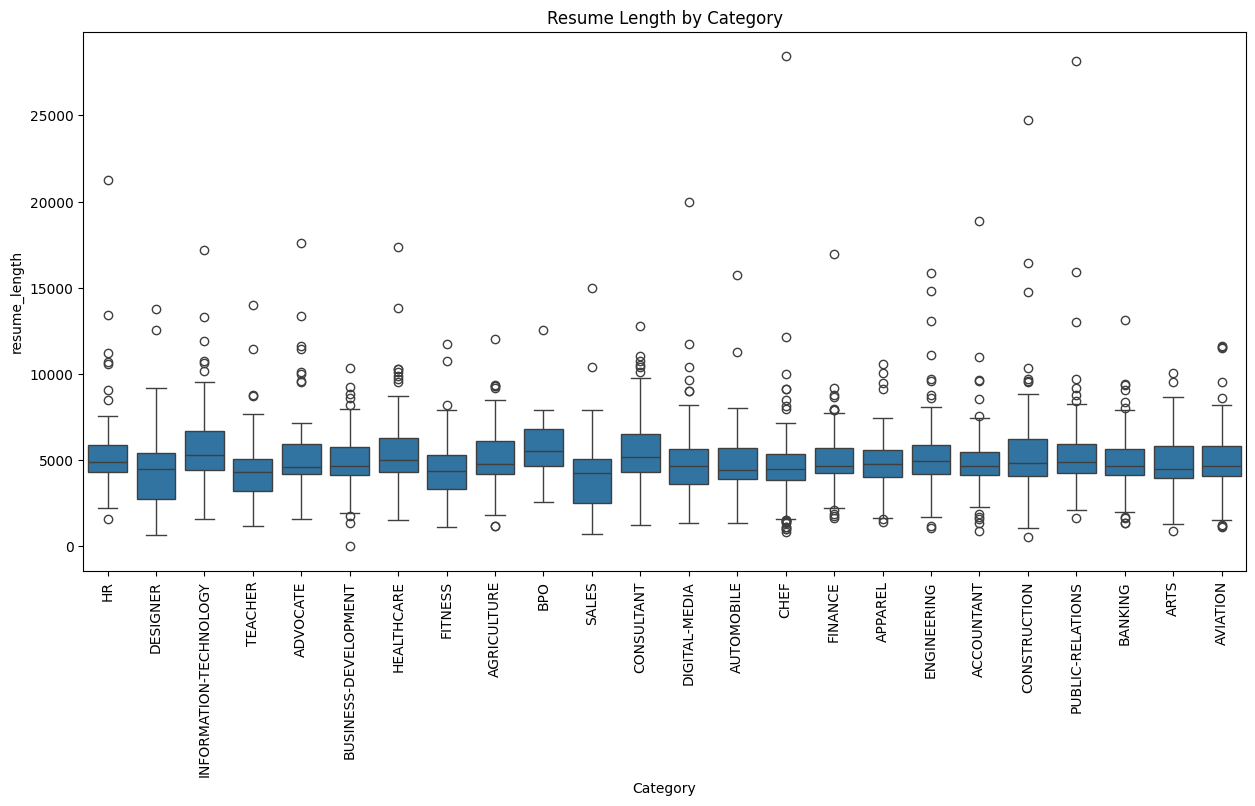

In [27]:
plt.figure(figsize=(15,7))

sns.boxplot(
    x='Category',
    y='resume_length',
    data=df
)

plt.xticks(rotation=90)

plt.title("Resume Length by Category")

plt.show()

5. **HEATMAP OF CATEGORY COUNTS**

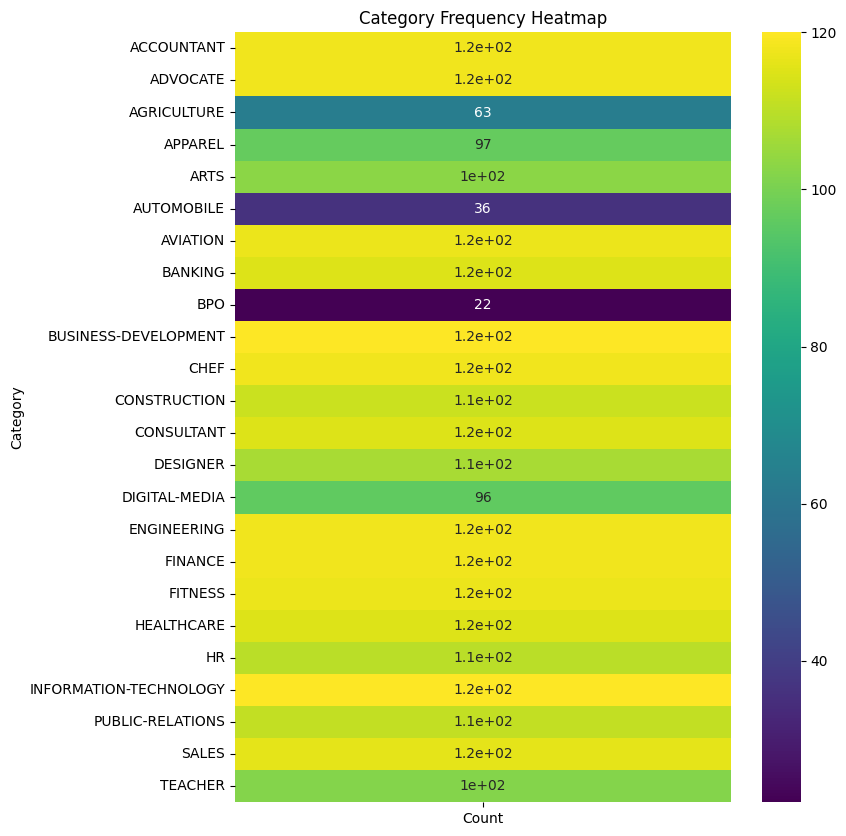

In [28]:
category_counts = df['Category'].value_counts().reset_index()

category_counts.columns = ['Category', 'Count']

pivot_data = category_counts.pivot_table(
    values='Count',
    index='Category'
)

plt.figure(figsize=(8,10))

sns.heatmap(
    pivot_data,
    annot=True,
    cmap='viridis'
)

plt.title("Category Frequency Heatmap")

plt.show()

6. **MODEL ACCURACY COMPARISON GRAPH**

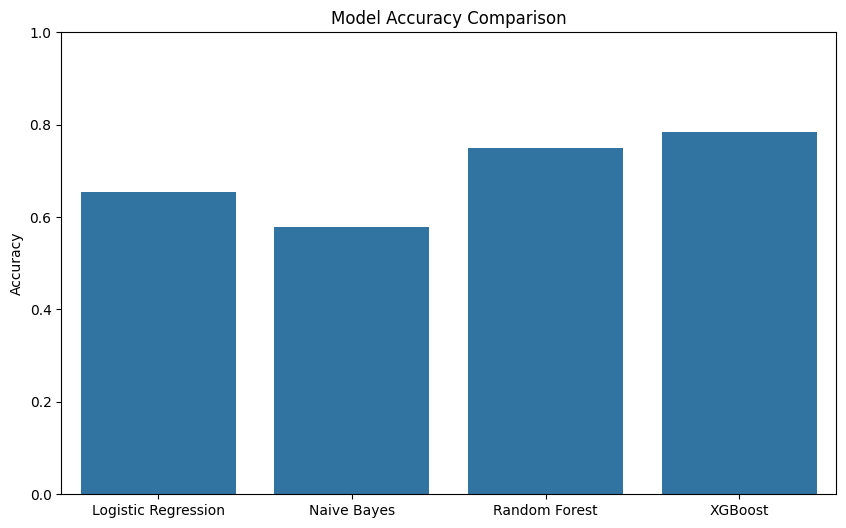

In [29]:
models = ['Logistic Regression', 'Naive Bayes', 'Random Forest', 'XGBoost']

accuracies = [
    accuracy_score(y_test, lr_preds),
    accuracy_score(y_test, nb_preds),
    accuracy_score(y_test, rf_preds),
    accuracy_score(y_test, xgb_preds)
]

plt.figure(figsize=(10,6))

sns.barplot(
    x=models,
    y=accuracies
)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.ylim(0,1)

plt.show()

7. **CONFUSION MATRIX**

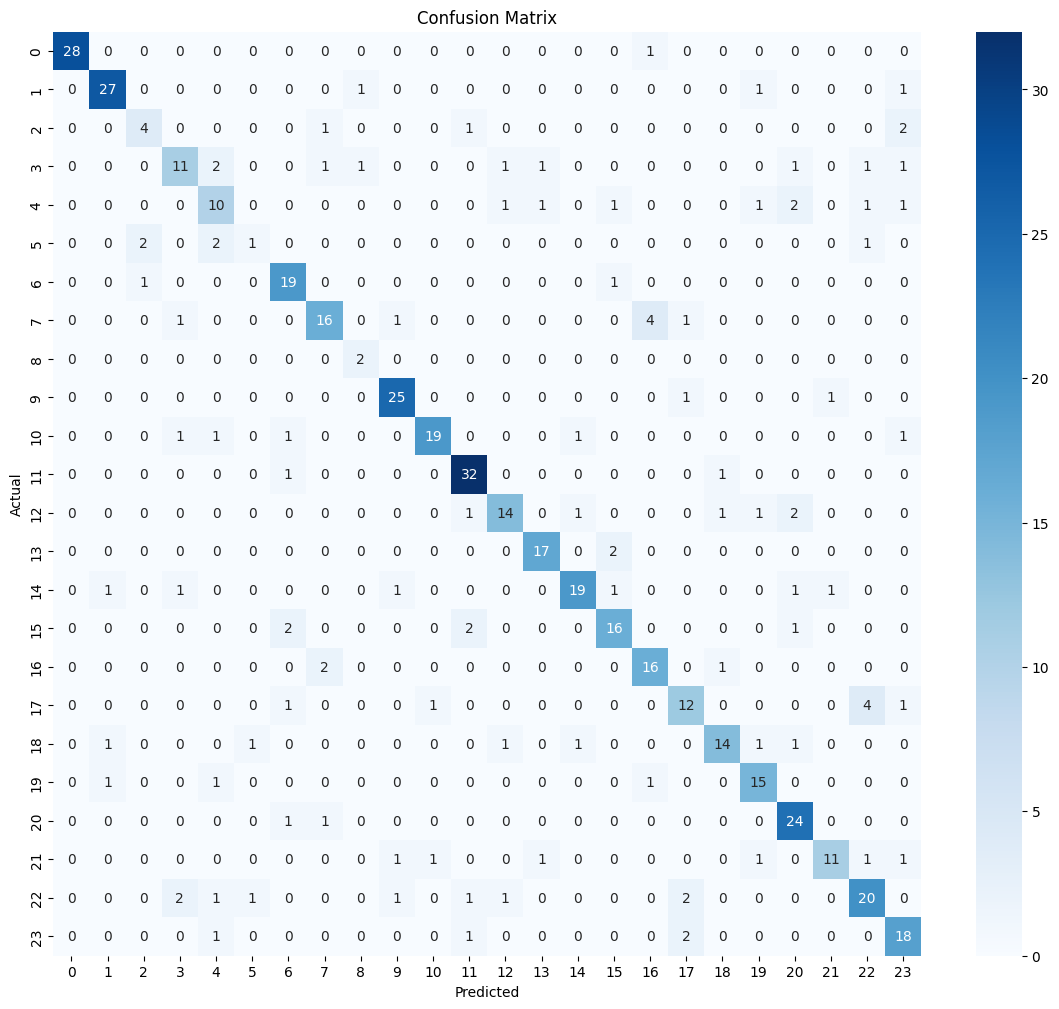

In [30]:
cm = confusion_matrix(y_test, xgb_preds)

plt.figure(figsize=(14,12))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

8. **SKILL FREQUENCY ANALYSIS**

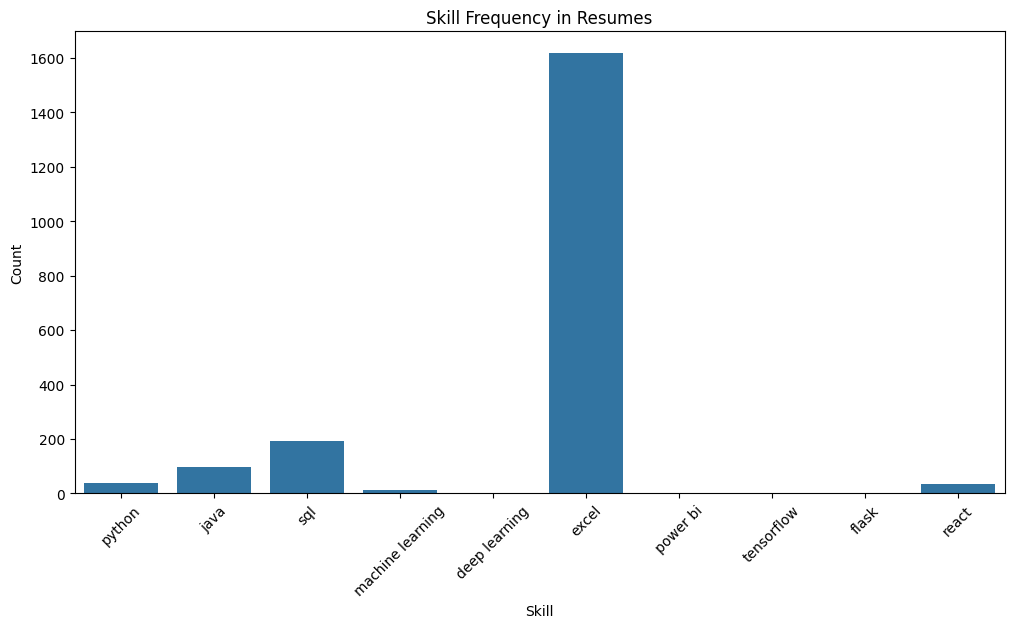

In [31]:
skills = [
    'python',
    'java',
    'sql',
    'machine learning',
    'deep learning',
    'excel',
    'power bi',
    'tensorflow',
    'flask',
    'react'
]

skill_count = {}

for skill in skills:
    count = df['cleaned_resume'].str.contains(skill).sum()
    skill_count[skill] = count

skill_df = pd.DataFrame({
    'Skill': skill_count.keys(),
    'Count': skill_count.values()
})

plt.figure(figsize=(12,6))

sns.barplot(
    x='Skill',
    y='Count',
    data=skill_df
)

plt.title("Skill Frequency in Resumes")

plt.xticks(rotation=45)

plt.show()

9. **TF-IDF FEATURE IMPORTANCE VISUALIZATION**

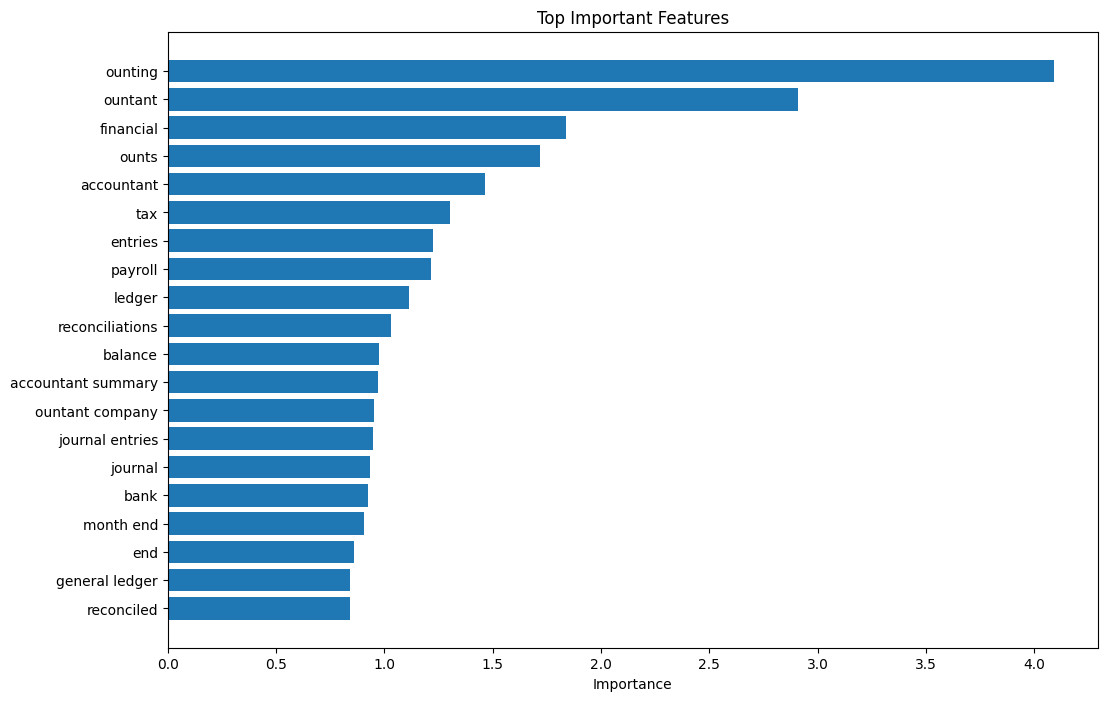

In [32]:
feature_names = tfidf.get_feature_names_out()

coefficients = lr_model.coef_[0]

top_features = np.argsort(coefficients)[-20:]

plt.figure(figsize=(12,8))

plt.barh(
    [feature_names[i] for i in top_features],
    coefficients[top_features]
)

plt.title("Top Important Features")

plt.xlabel("Importance")

plt.show()

10. **CATEGORY CORRELATION MAP**

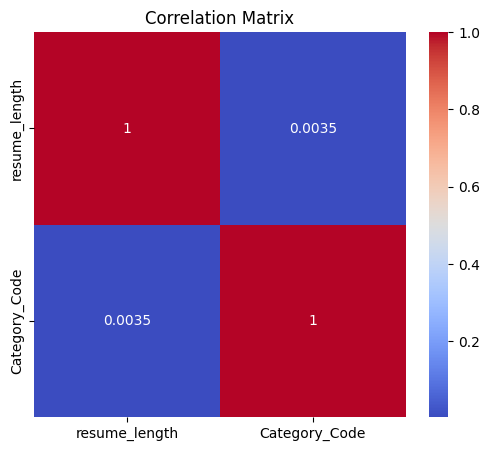

In [33]:
encoded_df = df.copy()

encoded_df['Category_Code'] = le.fit_transform(encoded_df['Category'])

corr = encoded_df[['resume_length', 'Category_Code']].corr()

plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

11. **INTERACTIVE PLOTS**

In [34]:
!pip install plotly

In [35]:
import plotly.express as px

fig = px.bar(
    df['Category'].value_counts(),
    title="Interactive Resume Categories"
)

fig.show()

12. **BIGRAM VISUALIZATION**

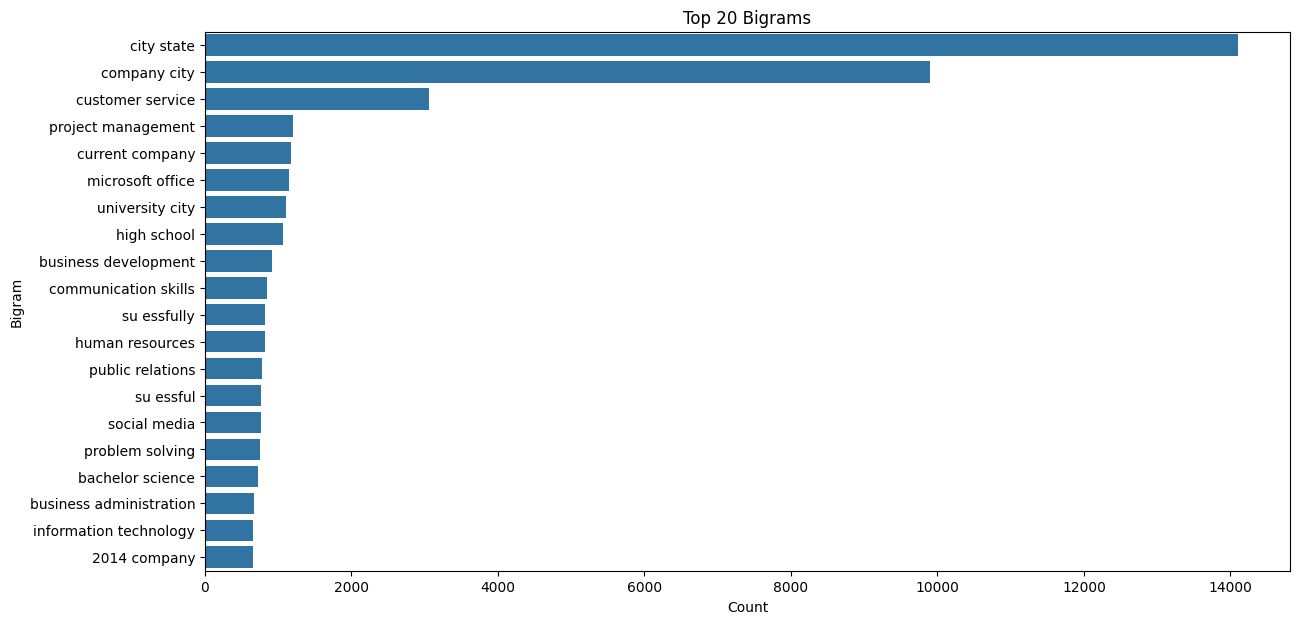

In [36]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(
    ngram_range=(2,2),
    stop_words='english'
)

bigram_matrix = cv.fit_transform(df['cleaned_resume'])

sum_words = bigram_matrix.sum(axis=0)

words_freq = [
    (word, sum_words[0, idx])
    for word, idx in cv.vocabulary_.items()
]

words_freq = sorted(
    words_freq,
    key=lambda x: x[1],
    reverse=True
)[:20]

bigram_df = pd.DataFrame(
    words_freq,
    columns=['Bigram', 'Count']
)

plt.figure(figsize=(14,7))

sns.barplot(
    x='Count',
    y='Bigram',
    data=bigram_df
)

plt.title("Top 20 Bigrams")

plt.show()

13. **MODEL PERFORMANCE TABLE**

In [37]:
performance_df = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracies
})

performance_df

,Model,Accuracy
0,Logistic Regression,0.653924
1,Naive Bayes,0.579477
2,Random Forest,0.750503
3,XGBoost,0.784708


**CLASSIFICATION REPORT**

In [38]:
print(classification_report(y_test, lr_preds))

              precision    recall  f1-score   support

           0       0.85      0.79      0.82        29
           1       0.51      0.63      0.57        30
           2       0.50      0.12      0.20         8
           3       0.50      0.35      0.41        20
           4       0.20      0.22      0.21        18
           5       1.00      0.17      0.29         6
           6       0.82      0.86      0.84        21
           7       0.73      0.70      0.71        23
           8       0.00      0.00      0.00         2
           9       0.95      0.74      0.83        27
          10       0.85      0.71      0.77        24
          11       0.90      0.76      0.83        34
          12       0.46      0.30      0.36        20
          13       0.73      0.84      0.78        19
          14       0.94      0.68      0.79        25
          15       0.52      0.67      0.58        21
          16       0.59      0.68      0.63        19
          17       1.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



**ATS Scoring Cell**

In [42]:
import re

def ats_score(resume_text):

    score = 0

    skills = [
        "python","machine learning","deep learning",
        "tensorflow","pytorch","sql","nlp",
        "data analysis","pandas","numpy"
    ]

    resume_lower = resume_text.lower()

    skill_count = sum(
        1 for skill in skills if skill in resume_lower
    )

    score += skill_count * 8

    if len(resume_text) > 1000:
        score += 10

    if re.search(r'\b(project|experience)\b', resume_lower):
        score += 10

    if re.search(r'\b(certification|certificate)\b', resume_lower):
        score += 10

    return min(score,100)

In [44]:
resume_text = sample_resume
score = ats_score(resume_text)
print("ATS Score:",score)

ATS Score: 40


**Job Description Matching**

In [45]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def jd_match(resume,jd):

    vectorizer = TfidfVectorizer()

    vectors = vectorizer.fit_transform([resume,jd])

    similarity = cosine_similarity(
        vectors[0:1],
        vectors[1:2]
    )[0][0]

    return round(similarity*100,2)

In [47]:
jd_text = "We are looking for a Python developer with strong skills in Machine Learning, Deep Learning, and TensorFlow. Experience with data analysis and NLP is a plus."
match_score = jd_match(resume_text,jd_text)

print(f"JD Match: {match_score}%")

JD Match: 46.35%


**Skill Gap Analysis**

In [48]:
def skill_gap_analysis(resume,jd):

    resume_words = set(resume.lower().split())

    jd_words = set(jd.lower().split())

    missing_skills = jd_words - resume_words

    return list(missing_skills)

In [49]:
missing = skill_gap_analysis(
    resume_text,
    jd_text
)

print("Missing Skills")

for skill in missing[:20]:
    print(skill)

Missing Skills
with
experience
looking
skills
strong
analysis
plus.
are
nlp
a
is
for
we
tensorflow.


**Resume Ranking**

In [51]:
resumes = [sample_resume] # Define resumes as a list of resume strings
candidate_scores = []

for resume in resumes:

    ats = ats_score(resume)

    jd_score = jd_match(
        resume,
        jd_text
    )

    final_score = (
        ats*0.4 +
        jd_score*0.6
    )

    candidate_scores.append(
        final_score
    )

ranked = sorted(
    enumerate(candidate_scores),
    key=lambda x:x[1],
    reverse=True
)

In [52]:
for rank,(idx,score) in enumerate(ranked,start=1):

    print(
        f"Rank {rank} | Resume {idx} | Score {score:.2f}"
    )

Rank 1 | Resume 0 | Score 43.81


**Acceptance/Rejection Prediction**

In [54]:
df['ATS_Score'] = df['cleaned_resume'].apply(ats_score)

df["Status"] = df["ATS_Score"].apply(
    lambda x:
    "Accepted"
    if x>=75
    else "Rejected"
)

In [55]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train,y_train)

prediction = model.predict(X_test)

**Explainable AI (SHAP)**

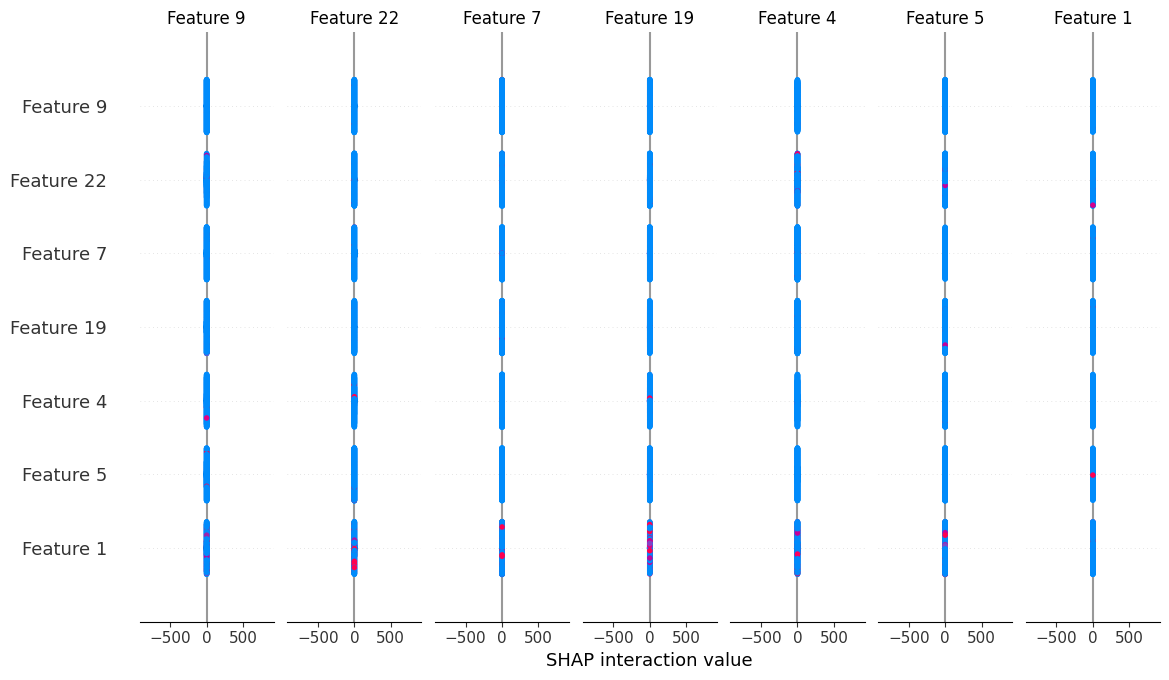

In [64]:
import shap

explainer = shap.TreeExplainer(model)

# Convert X_test to a dense array for SHAP calculations
# and disable additivity check as suggested by the error
shap_values = explainer.shap_values(X_test.toarray(), check_additivity=False)

# Also convert X_test to a dense array for summary_plot if it expects dense
shap.summary_plot(
    shap_values,
    X_test.toarray()
)

**FastAPI Backend**

In [60]:
from fastapi import FastAPI

app = FastAPI()

@app.post("/score")
def score_resume(text:str):

    score = ats_score(text)

    return {
        "ats_score":score
    }

In [61]:
!pip install pyngrok

from pyngrok import ngrok

public_url = ngrok.connect(8000)

print(public_url)

ERROR:pyngrok.process.ngrok:t=2026-06-06T04:14:53+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-06-06T04:14:53+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"


PyngrokNgrokError: The ngrok process errored on start: authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n.

**Database Integration**

In [62]:
import sqlite3

conn = sqlite3.connect(
    "hiremind.db"
)

cursor = conn.cursor()

cursor.execute("""
CREATE TABLE IF NOT EXISTS resumes(
id INTEGER PRIMARY KEY,
name TEXT,
score INTEGER
)
""")

In [66]:
name = "Candidate 1"
score = int(final_score) # Using final_score from previous ranking, converted to int

cursor.execute("""
INSERT INTO resumes
(name,score)
VALUES (?,?)
""",(name,score))

conn.commit()

**Real-Time Inference**

Save:

In [67]:
import joblib

joblib.dump(
    model,
    "hiremind_model.pkl"
)

['hiremind_model.pkl']

Load:

In [68]:
model = joblib.load(
    "hiremind_model.pkl"
)

Predict:

In [70]:
cleaned_new_resume = clean_resume(sample_resume)
new_resume_vector = tfidf.transform([cleaned_new_resume])

prediction = model.predict(
    new_resume_vector
)

**SAVE MODEL**

In [39]:
pickle.dump(lr_model, open('resume_model.pkl', 'wb'))

pickle.dump(tfidf, open('tfidf.pkl', 'wb'))

pickle.dump(le, open('label_encoder.pkl', 'wb'))

**TEST ON NEW RESUME**

In [40]:
def predict_resume(resume_text):

    cleaned = clean_resume(resume_text)

    vectorized = tfidf.transform([cleaned])

    prediction = lr_model.predict(vectorized)

    category = le.inverse_transform(prediction)

    return category[0]

**TEST SAMPLE**

In [41]:
sample_resume = """

Python developer skilled in Machine Learning,
Deep Learning, NLP, TensorFlow, Flask,
and Data Science projects.

"""

print(predict_resume(sample_resume))

DESIGNER
